# WRF Output Post-Processing

**Runnable companion to [`wrf-model-guide.md`](../wrf-model-guide.md).**

Running WRF needs an HPC build and gigabytes of input — but the *post-processing*
is pure Python. This notebook opens a `wrfout`-style NetCDF and does the everyday
tasks: map 2-m temperature, derive period precipitation from the accumulated
fields, overlay 10-m wind, and take a vertical cross-section.

> The sample file is generated on first run by `meteo_examples.sampledata` with
> the **same variable names, dimensions, and attributes as real wrfout**
> (`T2`, `RAINNC`, `RAINC`, `U10`, `V10`, `XLAT`, `XLONG`, `Times`). To use your
> own run, just point `xr.open_dataset()` at your `wrfout_d01_*` file — every
> other line is unchanged. Domain: Sunda Strait / West Java.

> For publication maps add coastlines with `cartopy` (`pip install -e ".[maps]"`).
> For diagnostics like CAPE/helicity use `wrf-python` on the real output.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from meteo_examples import sampledata

WRFOUT = "wrfout_d01_2024-01-15.nc"
if not os.path.exists(WRFOUT):
    sampledata.make_wrfout(WRFOUT)

ds = xr.open_dataset(WRFOUT)
plt.rcParams["figure.dpi"] = 110
print("times:", [t.decode() for t in ds["Times"].values])
ds

times: ['2024-01-15_00:00:00', '2024-01-15_06:00:00', '2024-01-15_12:00:00', '2024-01-15_18:00:00']


<xarray.Dataset> Size: 1MB
Dimensions:  (Time: 4, south_north: 100, west_east: 120)
Dimensions without coordinates: Time, south_north, west_east
Data variables:
    Times    (Time) |S19 76B b'2024-01-15_00:00:00' ... b'2024-01-15_18:00:00'
    T2       (Time, south_north, west_east) float32 192kB ...
    RAINNC   (Time, south_north, west_east) float32 192kB ...
    RAINC    (Time, south_north, west_east) float32 192kB ...
    U10      (Time, south_north, west_east) float32 192kB ...
    V10      (Time, south_north, west_east) float32 192kB ...
    XLAT     (south_north, west_east) float32 48kB ...
    XLONG    (south_north, west_east) float32 48kB ...
Attributes:
    TITLE:    SYNTHETIC wrfout for meteo-notes examples
    GRID_ID:  1
    DX:       5000.0
    DY:       5000.0

## 1 · 2-m temperature map

WRF stores `T2` in kelvin; convert to °C. `XLAT`/`XLONG` give the 2-D curvilinear coordinates.

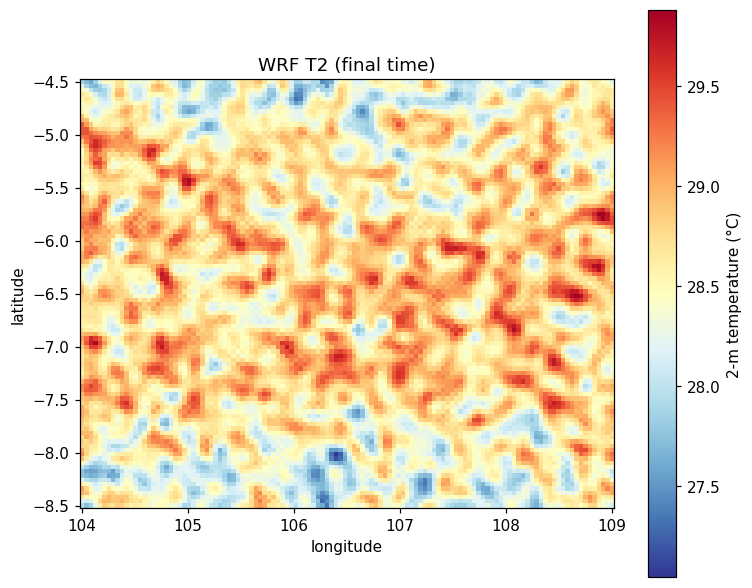

In [2]:
lat, lon = ds["XLAT"].values, ds["XLONG"].values
t2c = ds["T2"].isel(Time=-1).values - 273.15

fig, ax = plt.subplots(figsize=(7, 5.5))
pcm = ax.pcolormesh(lon, lat, t2c, cmap="RdYlBu_r", shading="auto")
plt.colorbar(pcm, label="2-m temperature (°C)")
ax.set(xlabel="longitude", ylabel="latitude", title="WRF T2 (final time)")
ax.set_aspect("equal"); plt.tight_layout()

## 2 · Derive period precipitation

WRF precip fields (`RAINNC` grid-scale, `RAINC` convective) are **accumulated**
since model start. Period precip = difference of total accumulation between two
output times — never plot the raw accumulated field as "rainfall".

domain-max period precip: 76.0 mm


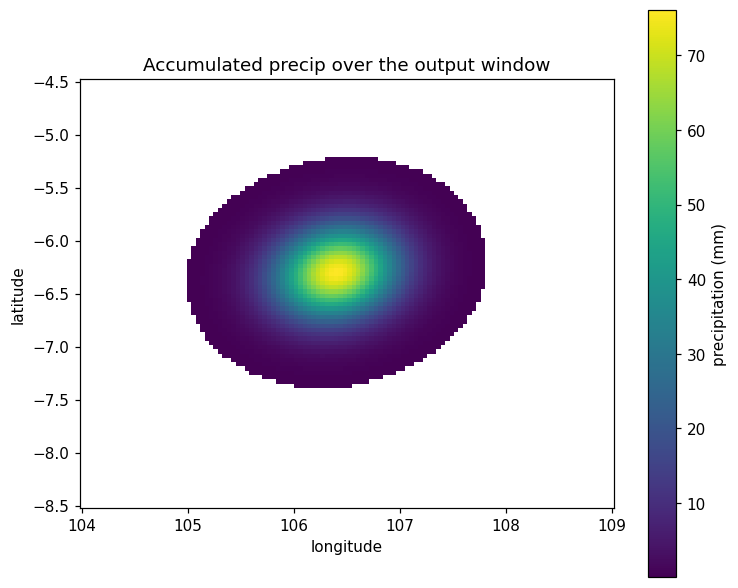

In [3]:
total = ds["RAINNC"] + ds["RAINC"]              # accumulated, mm
precip_period = (total.isel(Time=-1) - total.isel(Time=0)).values

fig, ax = plt.subplots(figsize=(7, 5.5))
pcm = ax.pcolormesh(lon, lat, np.ma.masked_less(precip_period, 0.1),
                    cmap="viridis", shading="auto")
plt.colorbar(pcm, label="precipitation (mm)")
ax.set(xlabel="longitude", ylabel="latitude",
       title="Accumulated precip over the output window")
ax.set_aspect("equal"); plt.tight_layout()
print(f"domain-max period precip: {precip_period.max():.1f} mm")

## 3 · 10-m wind overlaid on speed

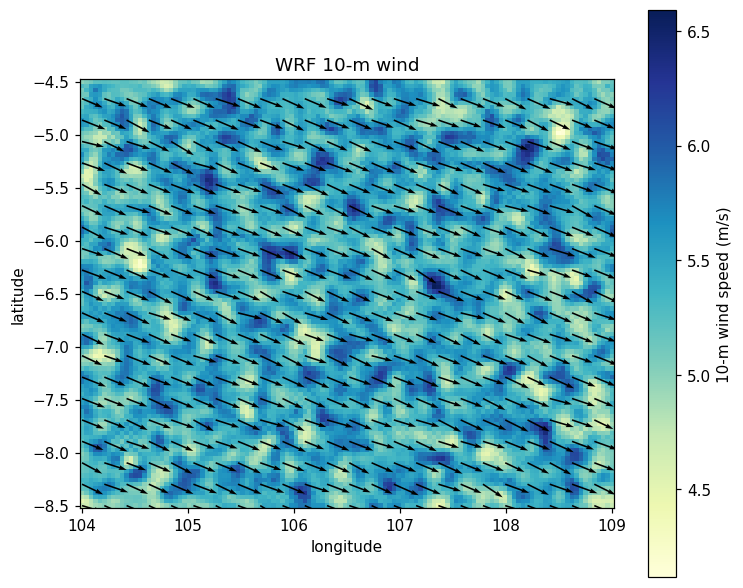

In [4]:
u, v = ds["U10"].isel(Time=-1).values, ds["V10"].isel(Time=-1).values
spd = np.sqrt(u**2 + v**2)
s = 5  # quiver subsample

fig, ax = plt.subplots(figsize=(7, 5.5))
pcm = ax.pcolormesh(lon, lat, spd, cmap="YlGnBu", shading="auto")
plt.colorbar(pcm, label="10-m wind speed (m/s)")
ax.quiver(lon[::s, ::s], lat[::s, ::s], u[::s, ::s], v[::s, ::s], scale=120, width=0.003)
ax.set(xlabel="longitude", ylabel="latitude", title="WRF 10-m wind")
ax.set_aspect("equal"); plt.tight_layout()

## 4 · West–east cross-section of T2

A quick latitude slice through the domain — the same indexing extends to 3-D
fields (`south_north`, `west_east`, `bottom_top`) for true vertical sections.

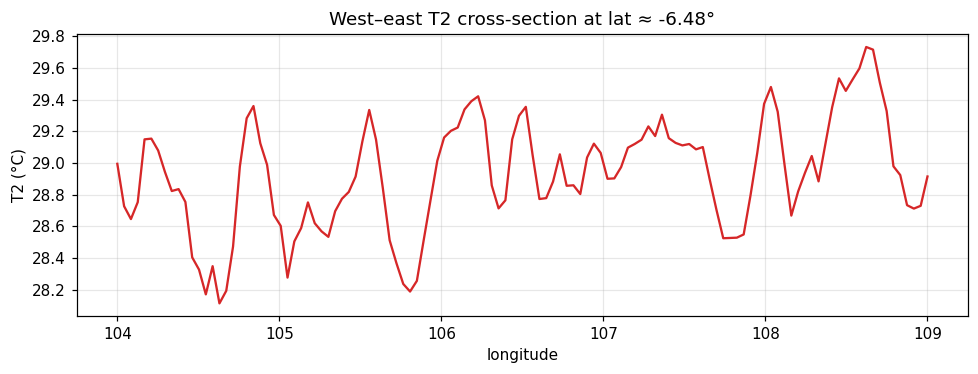

In [5]:
j = t2c.shape[0] // 2     # middle row
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(lon[j], t2c[j], color="C3")
ax.set(xlabel="longitude", ylabel="T2 (°C)",
       title=f"West–east T2 cross-section at lat ≈ {lat[j,0]:.2f}°")
ax.grid(alpha=0.3); plt.tight_layout()

---
### Apply to your own run
```python
ds = xr.open_dataset("wrfout_d01_2024-01-15_12:00:00")   # real output
# everything else in this notebook is unchanged
```
For verification against observations, feed `T2`/precip into
[`../../verification/notebooks/01_point_verification.ipynb`](../../verification/notebooks/01_point_verification.ipynb).